In [3]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.daily_data_loader import get_fwdpts, get_gt_yield
from data.resampled_data_loader import get_resampled_quotes

start_date = dt.date(2010, 1, 1)
end_date = dt.date(2025, 12, 31)

ccys = ['USD', 'EUR', 'JPY', 'GBP', 'CHF', 'NOK', 'SEK', 'AUD', 'NZD', 'CAD']

traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "NZDUSD",
]

freq = pd.Timedelta(minutes=15)
fx_price_dict = get_resampled_quotes(traded_instruments, start_date, end_date, freq)

fwdpts_tn_dict = get_fwdpts(traded_instruments, "tn",start_date, end_date)

ccy_yield_dict = get_gt_yield(ccys, "2Y", start_date, end_date)

In [28]:
# reload
import importlib

import strategy.ird_momo_strategy as irdm
importlib.reload(irdm)

import trading.aggressive_trader as at
importlib.reload(at)

<module 'trading.aggressive_trader' from '/Users/jinliu/Programming/Python/systematic-trading/src/systematic_trading/trading/aggressive_trader.py'>

In [29]:
strategy = irdm.IRDMomoStrategy(traded_instruments, fx_price_dict, ccy_yield_dict,
                        {
                            "ema_half_life_days": 10,
                            "tf_style": "American",
                            "trade_entry_time": "02:30",
                        })


In [30]:
signals = strategy.generate_signals()

In [31]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(
    traded_instruments,
    fx_price_dict,
    signals,
    execute_on_next_price_tick=False,
    fwdpts_tn_dict=fwdpts_tn_dict,
)

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

TypeError: AggressiveTrader.__init__() got an unexpected keyword argument 'fwdpts_tn_dict'

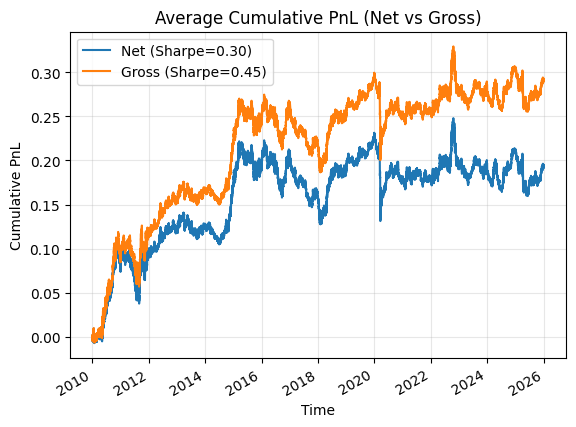

In [ ]:
freq_mult = pd.Timedelta(days=1) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [ ]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "GBPUSD"
date_range = (dt.date(2025, 1, 15), dt.date(2025, 10, 3))
close_price_df = fx_price_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)